In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [7]:
from google.colab import files

uploaded = files.upload()

Saving tesla_deliveries_dataset_2015_2025.csv to tesla_deliveries_dataset_2015_2025 (1).csv


In [8]:
import pandas as pd

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("✅ Dataset Loaded Successfully")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

✅ Dataset Loaded Successfully
Rows: 2640
Columns: 12


In [9]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [10]:
print("Columns:")
for col in df.columns:
    print(col)

Columns:
Year
Month
Region
Model
Estimated_Deliveries
Production_Units
Avg_Price_USD
Battery_Capacity_kWh
Range_km
CO2_Saved_tons
Source_Type
Charging_Stations


In [11]:
print("Missing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows: 0


In [12]:
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
df.head()

Dataset Shape: (2640, 12)

First 5 Rows:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


Average Tesla Price by Year:

Year
2015    85684.351167
2016    84776.998500
2017    85111.401667
2018    86111.865917
2019    83990.488833
2020    84159.935375
2021    83270.606125
2022    85680.589208
2023    84509.945625
2024    85999.219375
2025    84685.341833
Name: Avg_Price_USD, dtype: float64


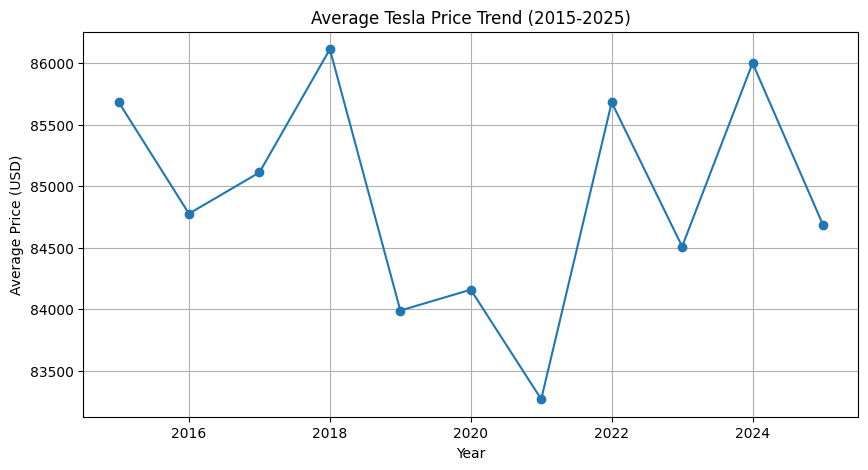

In [13]:
yearly_price = df.groupby('Year')['Avg_Price_USD'].mean()

print("Average Tesla Price by Year:\n")
print(yearly_price)

plt.figure(figsize=(10,5))

plt.plot(
    yearly_price.index,
    yearly_price.values,
    marker='o'
)

plt.title("Average Tesla Price Trend (2015-2025)")
plt.xlabel("Year")
plt.ylabel("Average Price (USD)")
plt.grid(True)

plt.show()

Total Deliveries by Year:

Year
2015    2375267
2016    2434081
2017    2350517
2018    2423104
2019    2404230
2020    2280336
2021    2335116
2022    2434220
2023    2382375
2024    2406899
2025    2368462
Name: Estimated_Deliveries, dtype: int64


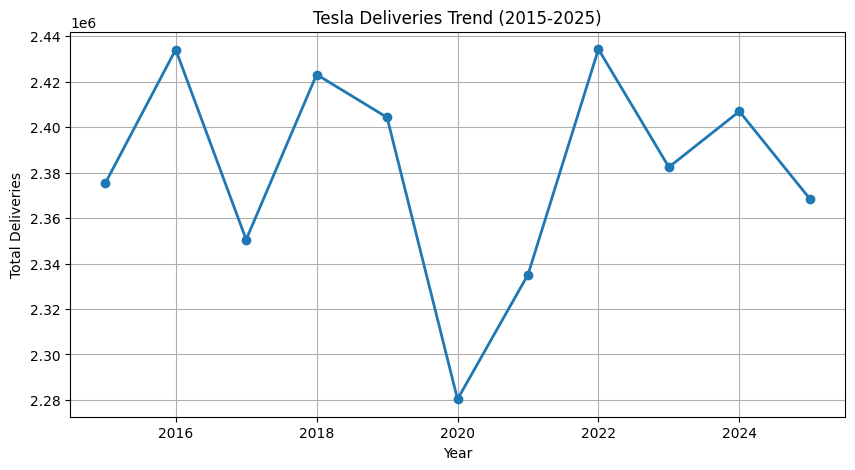

In [14]:
yearly_deliveries = df.groupby('Year')['Estimated_Deliveries'].sum()

print("Total Deliveries by Year:\n")
print(yearly_deliveries)

plt.figure(figsize=(10,5))

plt.plot(
    yearly_deliveries.index,
    yearly_deliveries.values,
    marker='o',
    linewidth=2
)

plt.title("Tesla Deliveries Trend (2015-2025)")
plt.xlabel("Year")
plt.ylabel("Total Deliveries")
plt.grid(True)

plt.show()

Total Deliveries by Model:

Model
Model S       5380385
Model 3       5321919
Model Y       5225284
Model X       5157240
Cybertruck    5109779
Name: Estimated_Deliveries, dtype: int64


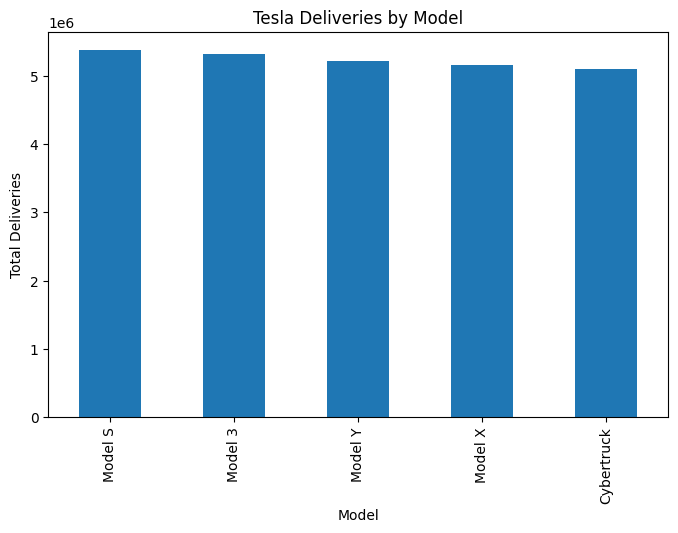

In [15]:
model_sales = df.groupby('Model')['Estimated_Deliveries'].sum().sort_values(ascending=False)

print("Total Deliveries by Model:\n")
print(model_sales)

plt.figure(figsize=(8,5))

model_sales.plot(kind='bar')

plt.title("Tesla Deliveries by Model")
plt.xlabel("Model")
plt.ylabel("Total Deliveries")

plt.show()

Average Price by Model:

Model
Model Y       86081.211061
Model S       85185.401269
Model 3       84528.004223
Cybertruck    84498.872159
Model X       84243.212936
Name: Avg_Price_USD, dtype: float64


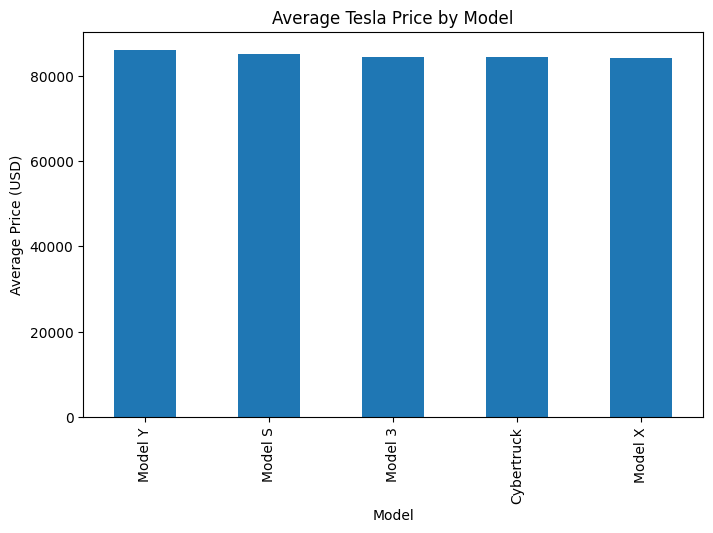

In [16]:
model_price = df.groupby('Model')['Avg_Price_USD'].mean().sort_values(ascending=False)

print("Average Price by Model:\n")
print(model_price)

plt.figure(figsize=(8,5))

model_price.plot(kind='bar')

plt.title("Average Tesla Price by Model")
plt.xlabel("Model")
plt.ylabel("Average Price (USD)")

plt.show()

In [17]:
numeric_cols = [
    'Estimated_Deliveries',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations'
]

corr_matrix = df[numeric_cols].corr()

print("Correlation with Avg_Price_USD:\n")
print(corr_matrix['Avg_Price_USD'].sort_values(ascending=False))

Correlation with Avg_Price_USD:

Avg_Price_USD           1.000000
Charging_Stations      -0.017790
Range_km               -0.017854
Battery_Capacity_kWh   -0.018203
Estimated_Deliveries   -0.027546
CO2_Saved_tons         -0.028523
Production_Units       -0.029263
Name: Avg_Price_USD, dtype: float64


In [18]:
region_price = df.groupby('Region')['Avg_Price_USD'].mean().sort_values(ascending=False)

print("Average Price by Region:\n")
print(region_price)

Average Price by Region:

Region
Europe           86107.731939
Asia             85161.733773
Middle East      84535.999091
North America    83823.896515
Name: Avg_Price_USD, dtype: float64


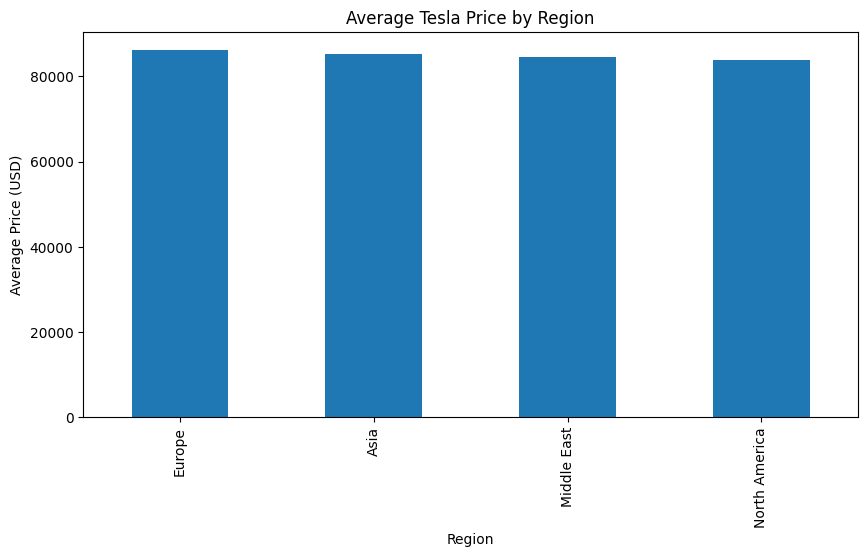

In [19]:
plt.figure(figsize=(10,5))

region_price.plot(kind='bar')

plt.title("Average Tesla Price by Region")
plt.xlabel("Region")
plt.ylabel("Average Price (USD)")

plt.show()

In [20]:
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

df['Region'] = le_region.fit_transform(df['Region'])
df['Model'] = le_model.fit_transform(df['Model'])
df['Source_Type'] = le_source.fit_transform(df['Source_Type'])

print("✅ Encoding Completed")

print("\nEncoded Region Values:")
print(df['Region'].unique())

print("\nEncoded Model Values:")
print(df['Model'].unique())

print("\nEncoded Source_Type Values:")
print(df['Source_Type'].unique())

✅ Encoding Completed

Encoded Region Values:
[1 0 3 2]

Encoded Model Values:
[2 3 1 4 0]

Encoded Source_Type Values:
[1 2 0]


In [21]:
X = df.drop('Avg_Price_USD', axis=1)

y = df['Avg_Price_USD']

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Variable:")
print(y.head())

Feature Matrix Shape: (2640, 11)
Target Shape: (2640,)

Target Variable:
0     92874.27
1     62205.65
2    117887.32
3     89294.91
4    114846.78
Name: Avg_Price_USD, dtype: float64


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("✅ Train-Test Split Completed")

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

print("\nTraining Target Shape:")
print(y_train.shape)

print("\nTesting Target Shape:")
print(y_test.shape)

✅ Train-Test Split Completed

Training Data Shape:
(2112, 11)

Testing Data Shape:
(528, 11)

Training Target Shape:
(2112,)

Testing Target Shape:
(528,)


In [23]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

print("✅ Linear Regression Model Trained Successfully")

✅ Linear Regression Model Trained Successfully


In [24]:
y_pred = lr.predict(X_test)

print("Actual Price        Predicted Price")

for i in range(5):
    print(f"{y_test.iloc[i]:.2f}        {y_pred[i]:.2f}")

Actual Price        Predicted Price
77791.05        86436.30
100029.16        84614.90
68450.11        86598.43
86288.53        84098.37
109940.95        85307.17


In [25]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Model Performance")
print("-----------------")
print("R2 Score :", round(r2,4))
print("MAE      :", round(mae,2))
print("RMSE     :", round(rmse,2))

Model Performance
-----------------
R2 Score : -0.0042
MAE      : 16770.9
RMSE     : 19459.72


In [26]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("✅ Random Forest Model Trained Successfully")

✅ Random Forest Model Trained Successfully


In [27]:
rf_pred = rf.predict(X_test)

print("Actual Price        Predicted Price")

for i in range(5):
    print(f"{y_test.iloc[i]:.2f}        {rf_pred[i]:.2f}")

Actual Price        Predicted Price
77791.05        89158.59
100029.16        94999.90
68450.11        83943.87
86288.53        88368.40
109940.95        78628.98


In [28]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print("Random Forest Performance")
print("-------------------------")
print("R2 Score :", round(rf_r2,4))
print("MAE      :", round(rf_mae,2))
print("RMSE     :", round(rf_rmse,2))

Random Forest Performance
-------------------------
R2 Score : -0.091
MAE      : 17373.99
RMSE     : 20283.76


In [29]:

corr_matrix = df.corr(numeric_only=True)

print(
    corr_matrix['Estimated_Deliveries']
    .sort_values(ascending=False)
)

Estimated_Deliveries    1.000000
Production_Units        0.994234
CO2_Saved_tons          0.836814
Month                   0.030877
Model                   0.004515
Charging_Stations       0.000753
Region                 -0.001206
Year                   -0.002863
Range_km               -0.006606
Battery_Capacity_kWh   -0.007765
Source_Type            -0.013190
Avg_Price_USD          -0.027546
Name: Estimated_Deliveries, dtype: float64


In [30]:
X = df.drop('Estimated_Deliveries', axis=1)

y = df['Estimated_Deliveries']

print("✅ New Target Variable Selected")

print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

print("\nTarget Preview:")
print(y.head())

✅ New Target Variable Selected
Feature Shape: (2640, 11)
Target Shape : (2640,)

Target Preview:
0    17646
1     3797
2     8411
3     6555
4    12374
Name: Estimated_Deliveries, dtype: int64


In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("✅ New Train-Test Split Completed")

print("\nX_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("\ny_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

✅ New Train-Test Split Completed

X_train Shape: (2112, 11)
X_test Shape : (528, 11)

y_train Shape: (2112,)
y_test Shape : (528,)


In [32]:
from sklearn.linear_model import LinearRegression

lr_delivery = LinearRegression()

lr_delivery.fit(X_train, y_train)

print("✅ Linear Regression Model Trained for Delivery Prediction")

✅ Linear Regression Model Trained for Delivery Prediction


In [33]:
delivery_pred = lr_delivery.predict(X_test)

print("Actual Deliveries     Predicted Deliveries")

for i in range(5):
    print(f"{y_test.iloc[i]}     {int(delivery_pred[i])}")

Actual Deliveries     Predicted Deliveries
6991     7560
9326     9391
9061     8804
8951     9378
8707     8911


In [34]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2_delivery = r2_score(y_test, delivery_pred)

mae_delivery = mean_absolute_error(y_test, delivery_pred)

rmse_delivery = np.sqrt(mean_squared_error(y_test, delivery_pred))

print("Delivery Prediction Performance")
print("-------------------------------")
print("R2 Score :", round(r2_delivery,4))
print("MAE      :", round(mae_delivery,2))
print("RMSE     :", round(rmse_delivery,2))

Delivery Prediction Performance
-------------------------------
R2 Score : 0.9901
MAE      : 310.13
RMSE     : 383.58


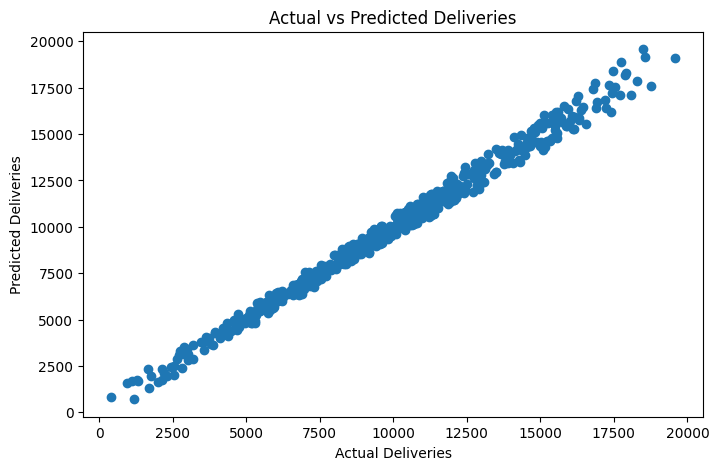

In [35]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, delivery_pred)

plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted Deliveries")

plt.show()

In [36]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_delivery.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

print(coefficients)

                 Feature  Coefficient
3                  Model     4.804767
8         CO2_Saved_tons     2.155679
6   Battery_Capacity_kWh     1.881709
1                  Month     1.445077
0                   Year     0.967453
4       Production_Units     0.768549
10     Charging_Stations     0.002224
5          Avg_Price_USD     0.000453
2                 Region    -3.399724
7               Range_km    -3.629959
9            Source_Type    -3.976727


In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest R2 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'n_estimators': 100}

Best R2 Score:
0.9880360164984637


In [38]:
yearly_data = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

print(yearly_data)

    Year  Estimated_Deliveries
0   2015               2375267
1   2016               2434081
2   2017               2350517
3   2018               2423104
4   2019               2404230
5   2020               2280336
6   2021               2335116
7   2022               2434220
8   2023               2382375
9   2024               2406899
10  2025               2368462


In [39]:
from sklearn.linear_model import LinearRegression

X_year = yearly_data[['Year']]
y_year = yearly_data['Estimated_Deliveries']

forecast_model = LinearRegression()

forecast_model.fit(X_year, y_year)

print("✅ Forecast Model Trained Successfully")

✅ Forecast Model Trained Successfully


In [40]:
future_years = pd.DataFrame({
    'Year': [2026, 2027, 2028]
})

future_predictions = forecast_model.predict(future_years)

forecast_df = pd.DataFrame({
    'Year': [2026, 2027, 2028],
    'Forecasted_Deliveries': future_predictions.astype(int)
})

print(forecast_df)

   Year  Forecasted_Deliveries
0  2026                2376197
1  2027                2375342
2  2028                2374487


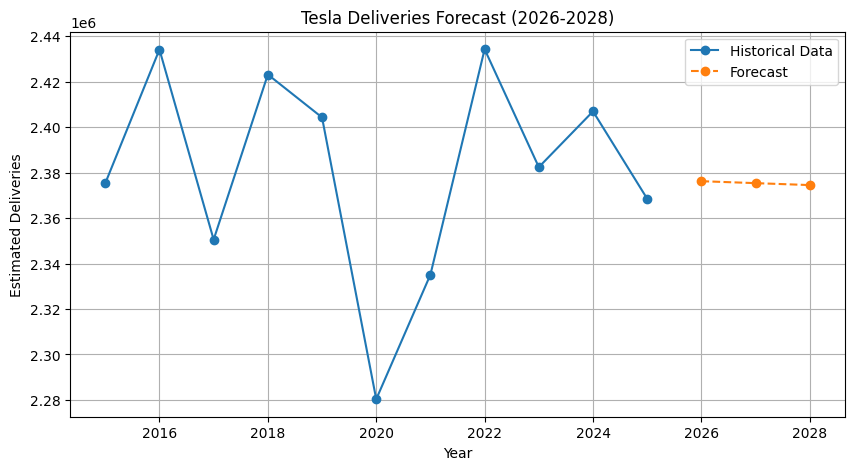

In [41]:
plt.figure(figsize=(10,5))

plt.plot(
    yearly_data['Year'],
    yearly_data['Estimated_Deliveries'],
    marker='o',
    label='Historical Data'
)

plt.plot(
    forecast_df['Year'],
    forecast_df['Forecasted_Deliveries'],
    marker='o',
    linestyle='--',
    label='Forecast'
)

plt.title("Tesla Deliveries Forecast (2026-2028)")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.grid(True)

plt.show()